# Explore the Storm Arthur (June 2026) data — GOES inputs & flood-warning outputs

What we have for the same-day flood task: **inputs** = GOES-19 hourly imagery (all 16 bands, `/mnt/disk4/recent-goes`); **outputs** = NWS FF/FA warnings (`StormArthurEvaluation/data/flood_warnings_2026.parquet`) rasterized to a 50 km CONUS-land grid. Descriptive only.

## 0 · Setup

In [1]:
import sys
from datetime import datetime, timedelta
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.wkb
import xarray as xr

SIG_ROOT = Path.cwd()
while not (SIG_ROOT / "siggrid.py").exists() and SIG_ROOT != SIG_ROOT.parent:
    SIG_ROOT = SIG_ROOT.parent
sys.path.insert(0, str(SIG_ROOT))
from siggrid import build_grid_cells, CELL_KM, STATES_GEOJSON, _NON_CONUS  # noqa: E402

GOES_DIR = Path("/mnt/disk4/recent-goes")
WARN_PARQUET = SIG_ROOT / "data/flood_warnings_2026.parquet"
plt.rcParams.update({"figure.dpi": 110})

def scan_token(p):
    for part in p.name.split("_"):
        if part.startswith("s") and part[1:].isdigit():
            return part
    return p.name

def scan_utc(p):
    return datetime.strptime(scan_token(p)[1:12], "%Y%j%H%M")    # UTC scan-start time

files = sorted(GOES_DIR.glob("*/2026/06/*/*.nc"), key=scan_token)
print(f"{len(files)} GOES NetCDF files under {GOES_DIR}")

528 GOES NetCDF files under /mnt/disk4/recent-goes


## 1 · Inputs — the GOES imagery we have

date range : 2026-06-01  ->  2026-06-22   (22 days)
per day    : 24-24 frames  (hourly)
UTC hours  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]   <- full 24-hour cycle each day
one file   : MCMIPC = all 16 ABI bands, CONUS sector, 2 km, ~1500x2500 px


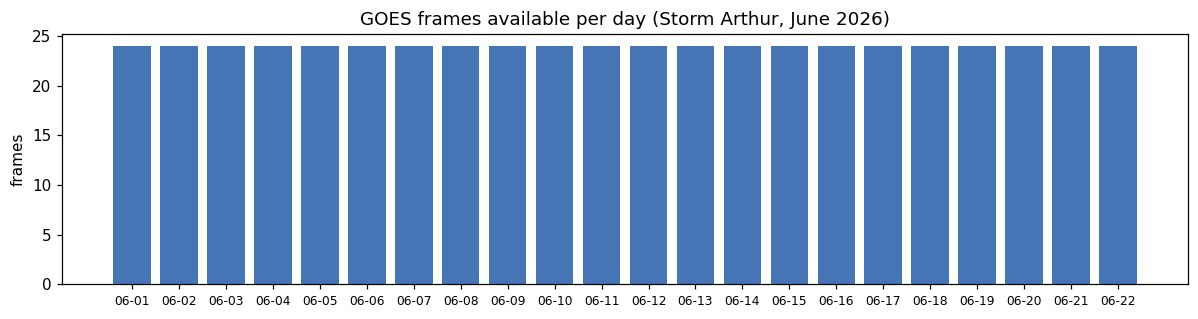

In [2]:
times = [scan_utc(p) for p in files]
days = sorted({t.date() for t in times})
per_day = pd.Series([t.date() for t in times]).value_counts().sort_index()
hours = sorted({t.hour for t in times})

print(f"date range : {days[0]}  ->  {days[-1]}   ({len(days)} days)")
print(f"per day    : {per_day.min()}-{per_day.max()} frames  (hourly)")
print(f"UTC hours  : {hours}   <- full 24-hour cycle each day")
print(f"one file   : MCMIPC = all 16 ABI bands, CONUS sector, 2 km, ~1500x2500 px")

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar([d.strftime('%m-%d') for d in per_day.index], per_day.values, color="#4575b4")
ax.set_title("GOES frames available per day (Storm Arthur, June 2026)"); ax.set_ylabel("frames")
plt.xticks(rotation=0, fontsize=8); plt.tight_layout(); plt.show()

## 2 · The 16 ABI bands

Bands 1–6 are reflectance (visible/near-IR, daytime only); 7–16 are brightness temperature (K, day & night).

| band | µm | name | type |
|---|---|---|---|
| 1–3 | 0.47/0.64/0.86 | Blue / Red / Veggie | reflectance |
| 4–6 | 1.37/1.6/2.2 | Cirrus / Snow / particle size | reflectance |
| 7 | 3.9 | Shortwave window | BT |
| 8–10 | 6.2/6.9/7.3 | Water vapour (upper/mid/low) | BT |
| 11–12 | 8.4/9.6 | Cloud phase / Ozone | BT |
| 13–14 | 10.3/11.2 | **Clean/IR window (cloud-top temp)** | BT |
| 15–16 | 12.3/13.3 | Dirty window / **CO₂ (cloud height)** | BT |

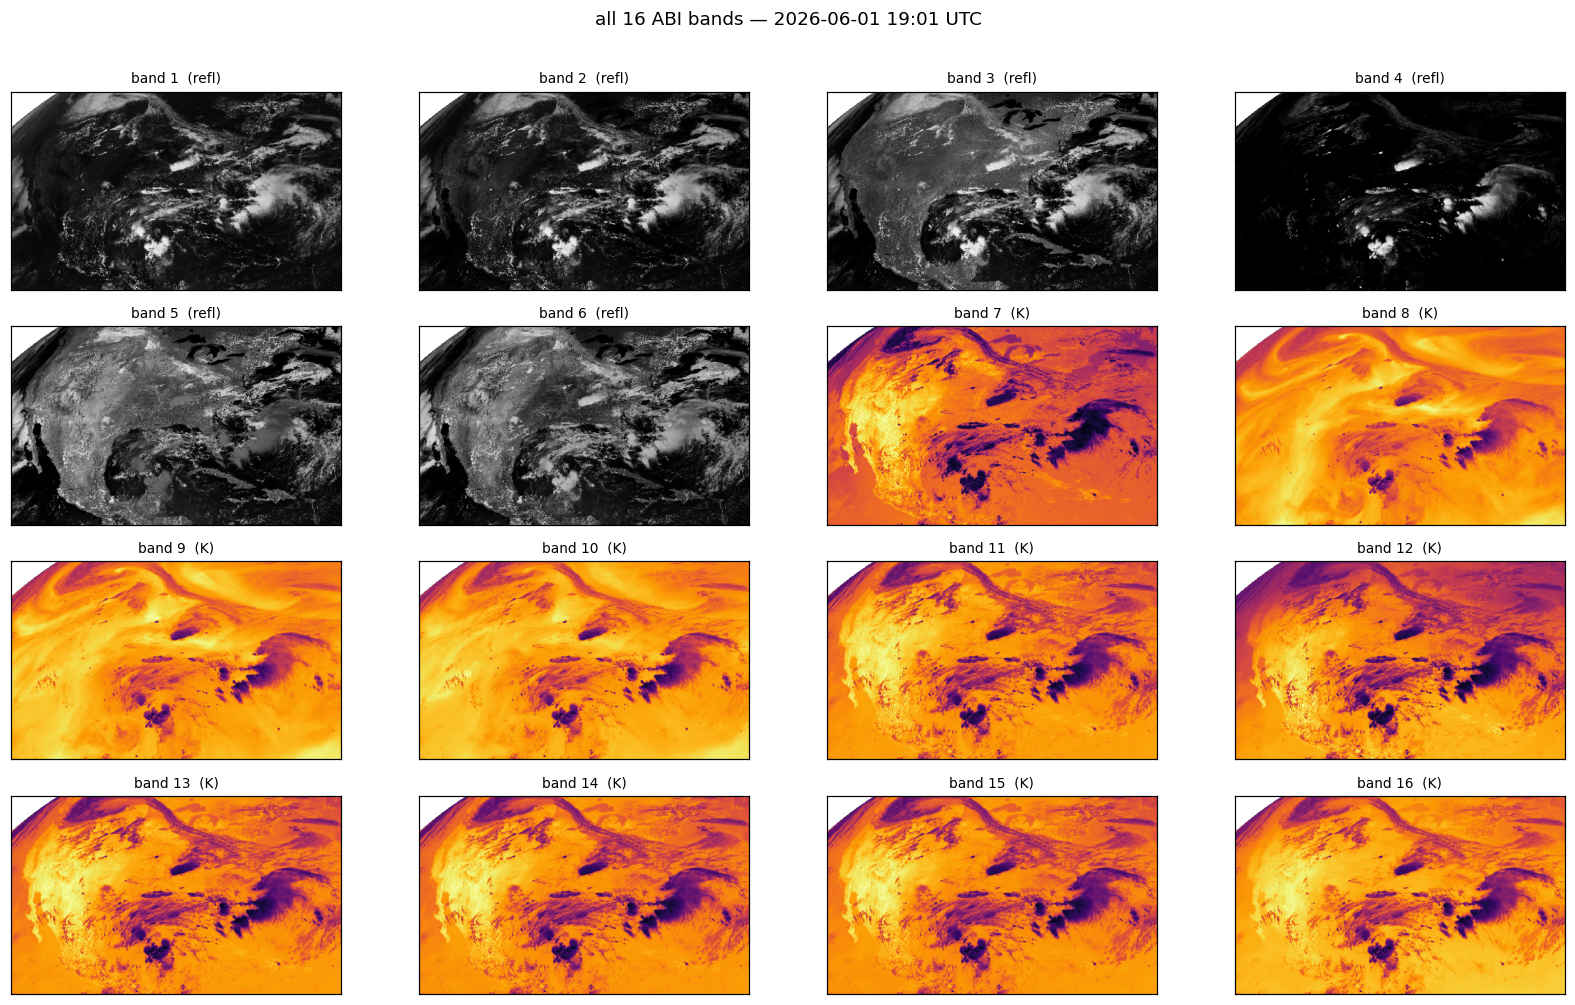

In [3]:
frame = next(p for p in files if scan_utc(p).hour == 19)        # ~afternoon UTC
ds = xr.open_dataset(frame)
fig, axes = plt.subplots(4, 4, figsize=(15, 9))
for b, ax in zip(range(1, 17), axes.flat):
    a = ds[f"CMI_C{b:02d}"].values[::5, ::5]                     # subsample for display
    refl = b <= 6
    im = ax.imshow(a, cmap="gray" if refl else "inferno")
    ax.set_title(f"band {b}  ({'refl' if refl else 'K'})", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
ds.close()
fig.suptitle(f"all 16 ABI bands — {scan_utc(frame):%Y-%m-%d %H:%M} UTC", y=1.01)
plt.tight_layout(); plt.show()

## 3 · UTC vs local day

GOES filenames are UTC; floods are a local-day event, so the model bins frames into CST days (CST = UTC−6).

## 4 · Outputs — the flood warnings (our target)

columns: ['kind', 'source', 'event_id', 'phenomena', 'issue_date', 'expire_date', 'area_km2', 'flood_cause', 'damage_property_usd', 'geometry', 'issue_day']

1168 warnings  |  by type: {'FF': 928, 'FA': 240}
area km2: median 2983, range 24-48327


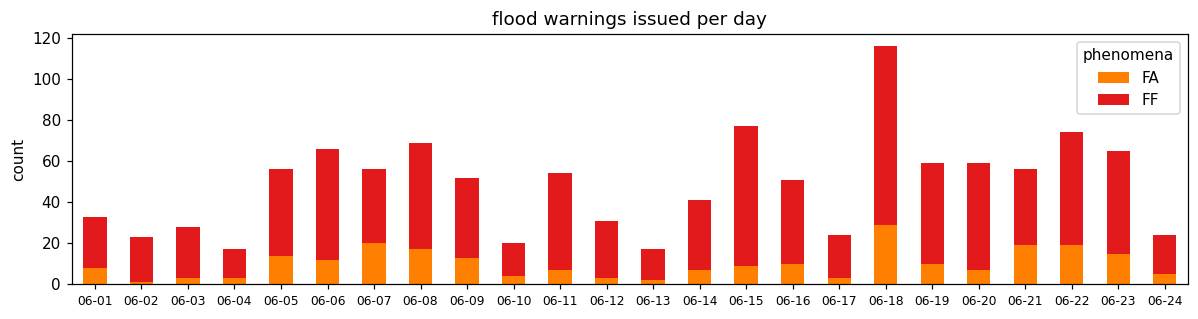

In [4]:
w = pd.read_parquet(WARN_PARQUET)
w["geometry"] = w["geometry"].apply(shapely.wkb.loads)
w = gpd.GeoDataFrame(w, geometry="geometry", crs=4326)
print("columns:", list(w.columns))
print(f"\n{len(w)} warnings  |  by type: {w['phenomena'].value_counts().to_dict()}")
print(f"area km2: median {w['area_km2'].median():.0f}, "
      f"range {w['area_km2'].min():.0f}-{w['area_km2'].max():.0f}")

per_day = (w.groupby([w['issue_day'].dt.date, "phenomena"]).size()
           .unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(11, 3))
per_day.plot(kind="bar", stacked=True, ax=ax,
             color={"FF": "#e31a1c", "FA": "#ff7f00"})
ax.set_title("flood warnings issued per day"); ax.set_xlabel(""); ax.set_ylabel("count")
ax.set_xticklabels([d.strftime('%m-%d') for d in per_day.index], rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

/tmp/ipykernel_1018283/858958218.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(); ax.set_title(f"flood warnings on {busy} (busiest day)")
/tmp/ipykernel_1018283/858958218.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(); ax.set_title(f"flood warnings on {busy} (busiest day)")


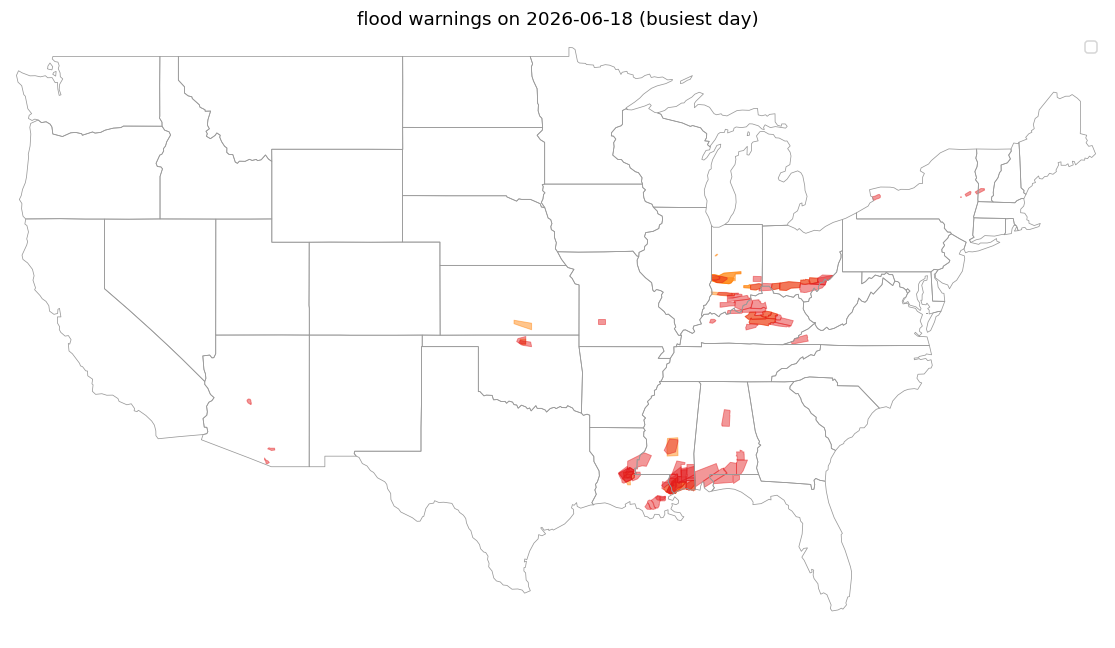

In [5]:
states = gpd.read_file(STATES_GEOJSON)
states = states[~states["name"].isin(_NON_CONUS)].to_crs(4326)
busy = w.groupby(w['issue_day'].dt.date).size().idxmax()
wd = w[w['issue_day'].dt.date == busy]

fig, ax = plt.subplots(figsize=(11, 6))
states.boundary.plot(ax=ax, color="#999", lw=0.5)
for ph, color in [("FA", "#ff7f00"), ("FF", "#e31a1c")]:
    sub = wd[wd['phenomena'] == ph]
    if len(sub):
        sub.plot(ax=ax, color=color, alpha=0.45, edgecolor=color, lw=0.6,
                 label=f"{ph} ({len(sub)})")
ax.set_xlim(-125, -66.5); ax.set_ylim(24, 50); ax.set_axis_off()
ax.legend(); ax.set_title(f"flood warnings on {busy} (busiest day)")
plt.tight_layout(); plt.show()

## 5 · The output grid — what the model predicts

The target is not the raw polygons but a fixed **50 km CONUS-land grid**
(`config.build_grid_cells`). For each day, every cell a warning polygon touches becomes a
1 → a `(rows, cols)` map of 0/1. That binary grid is exactly what the model outputs.

50 km grid: (59, 95) cells, 3360 over land


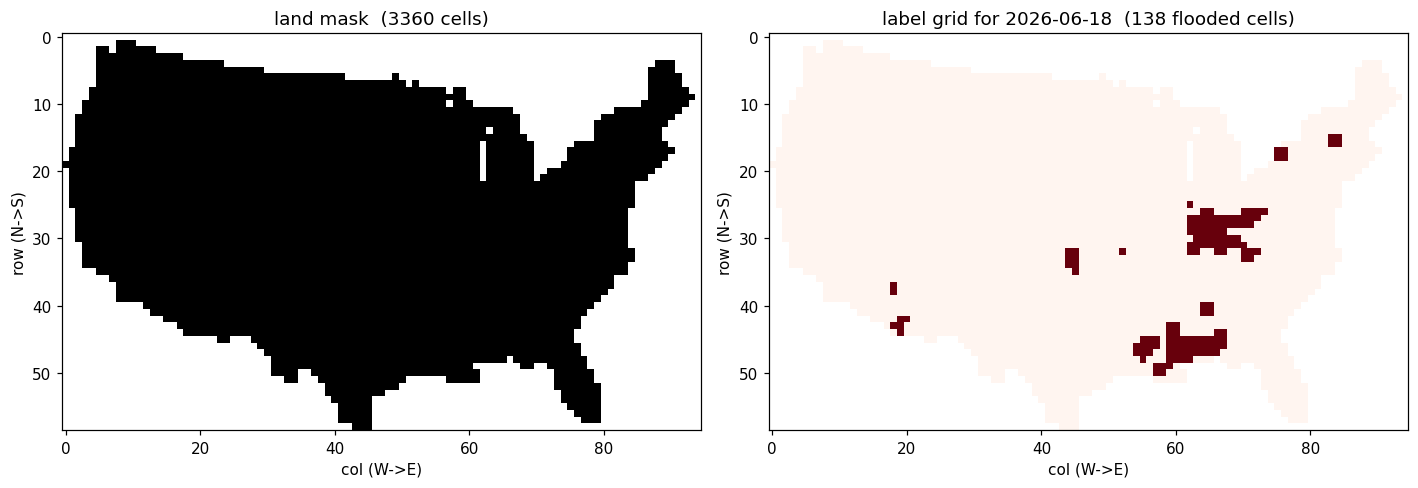

In [6]:
cells, GRID_R, GRID_C, land_mask = build_grid_cells()
print(f"{CELL_KM} km grid: ({GRID_R}, {GRID_C}) cells, {int(land_mask.sum())} over land")

lab = np.zeros((GRID_R, GRID_C), np.float32)
j = gpd.sjoin(cells, wd[["geometry"]], predicate="intersects", how="inner")
lab[cells.loc[j.index.unique(), "R"], cells.loc[j.index.unique(), "C"]] = 1.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].imshow(land_mask, cmap="Greys", interpolation="none")
ax[0].set_title(f"land mask  ({int(land_mask.sum())} cells)")
ax[1].imshow(np.where(land_mask, 0.12, np.nan), cmap="Greys", vmin=0, vmax=1)
ax[1].imshow(np.where(land_mask, lab, np.nan), cmap="Reds", vmin=0, vmax=1, interpolation="none")
ax[1].set_title(f"label grid for {busy}  ({int(lab.sum())} flooded cells)")
for a in ax: a.set_xlabel("col (W->E)"); a.set_ylabel("row (N->S)")
plt.tight_layout(); plt.show()

## What we have
- **Inputs:** GOES-19, 24 hourly frames/day, all 16 bands, ~1500×2500, Jun 1–22. IR bands (13/16) see deep convection; visible daytime-only.
- **Outputs:** FF/FA warnings → 50 km 0/1 grid/day (~2–3% of land cells positive).
- **Task:** from a day's imagery, predict that day's warning grid.